# Modélisation ACP - Île-de-France (3.3/3)

**Auteurs :** Leopold Mopita  
**Phase :** Machine Learning - Analyse en Composantes Principales (ACP)

###  Objectif de ce Notebook
L'objectif de l'ACP est de réduire la dimensionnalité de nos données et de comprendre les **corrélations profondes** entre nos variables quantitatives. 
Nous allons projeter nos variables (Surface, Consommation Théorique, Consommation Réelle, et Année de construction) sur un plan en 2D pour identifier :
* L'effet de taille (ce qui augmente ensemble).
* Les oppositions (ex: est-ce qu'un bâtiment récent fait baisser la consommation ?).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

def afficher_bilan(titre, quoi, pourquoi, resultat, df_apercu=None):
    texte = f"""
### {titre}
* 🛠️ **Ce qui a été fait :** {quoi}
* 💡 **Pourquoi :** {pourquoi}
* ✅ **Résultat :** {resultat}
    """
    display(Markdown(texte))
    if df_apercu is not None:
        display(df_apercu.head())

afficher_bilan("🚀 Environnement ACP prêt", 
               "Importation de Scikit-Learn (PCA, StandardScaler) et Matplotlib.", 
               "L'ACP nécessite des outils mathématiques d'algèbre linéaire (calcul de valeurs propres et vecteurs propres) fournis par Scikit-Learn.", 
               "Librairies chargées.")


### 🚀 Environnement ACP prêt
* 🛠️ **Ce qui a été fait :** Importation de Scikit-Learn (PCA, StandardScaler) et Matplotlib.
* 💡 **Pourquoi :** L'ACP nécessite des outils mathématiques d'algèbre linéaire (calcul de valeurs propres et vecteurs propres) fournis par Scikit-Learn.
* ✅ **Résultat :** Librairies chargées.
    

##  Étape 1 : Préparation et Standardisation
l'ACP doit absolument être réalisée sur des données **Centrées et Réduites** (ACP Normée). Sans cela, la variable avec la plus grande unité (la consommation en milliers de kWh) dicterait à elle seule toute la variance, écrasant l'année de construction ou la surface.

In [2]:
# 1. Chargement des données
NOM_FICHIER_PROPRE = "Data_IDF_Propre.csv"
df = pd.read_csv(NOM_FICHIER_PROPRE)

# 2. Sélection des variables quantitatives pour l'ACP
features_acp = ['Surface', 'Conso_Theorique_kWh', 'Conso_Reelle_kWh', 'annee_construction']

# On supprime les lignes ayant des valeurs manquantes sur ces colonnes précises
df_pca = df.dropna(subset=features_acp).copy()
X = df_pca[features_acp]

# 3. Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

afficher_bilan(
    titre="Standardisation pour l'ACP Normée",
    quoi="Extraction des 4 variables continues et application d'un StandardScaler.",
    pourquoi="Pour s'assurer que chaque variable pèse le même poids (variance = 1) lors du calcul de la matrice de covariance.",
    resultat=f"Matrice de {len(X_scaled):,} logements prête pour l'extraction des composantes principales."
)

C:\Users\mopit\AppData\Local\Temp\ipykernel_4876\2927764472.py:3: DtypeWarning: Columns (0: Code IRIS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(NOM_FICHIER_PROPRE)



### Standardisation pour l'ACP Normée
* 🛠️ **Ce qui a été fait :** Extraction des 4 variables continues et application d'un StandardScaler.
* 💡 **Pourquoi :** Pour s'assurer que chaque variable pèse le même poids (variance = 1) lors du calcul de la matrice de covariance.
* ✅ **Résultat :** Matrice de 40,585 logements prête pour l'extraction des composantes principales.
    

##  Étape 2 : L'Éboulis des Valeurs Propres (Scree Plot)
L'ACP crée de nouveaux axes (les composantes principales). La première composante capte le maximum de variance (d'information), la deuxième capte ce qu'il reste, etc.
Le graphique de l'éboulis des valeurs propres nous permet de savoir quel pourcentage d'information nous conservons si nous ne gardons que 2 axes pour faire nos graphiques.

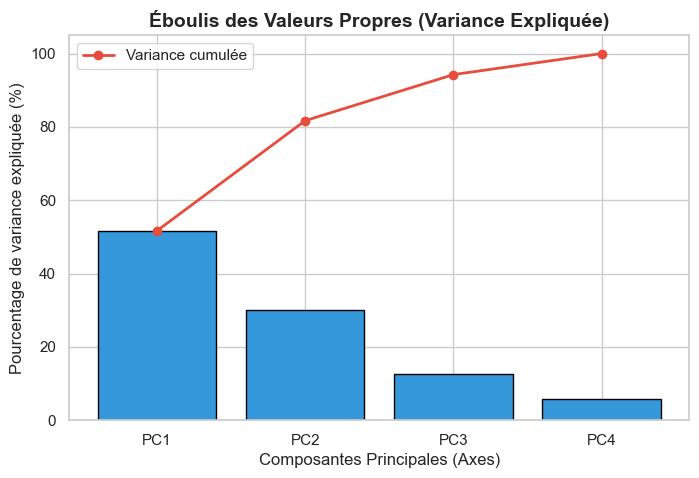


### Analyse de l'Éboulis
* 🛠️ **Ce qui a été fait :** Calcul de l'ACP et tracé de la variance expliquée par chaque axe factoriel.
* 💡 **Pourquoi :** Pour valider qu'une représentation en 2 dimensions (un plan) est suffisante pour résumer nos données.
* ✅ **Résultat :** Les 2 premiers axes (PC1 et PC2) concentrent à eux seuls **81.7%** de l'information totale ! C'est excellent, nous pouvons faire notre cercle des corrélations sans perdre trop d'information.
    

In [3]:
# 1. Modélisation ACP
pca = PCA()
pca.fit(X_scaled)

# 2. Récupération de la variance expliquée par chaque axe
variance_expliquee = pca.explained_variance_ratio_ * 100

# 3. Graphique (Scree Plot)
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(variance_expliquee) + 1), variance_expliquee, color='#3498db', edgecolor='black')
plt.plot(range(1, len(variance_expliquee) + 1), np.cumsum(variance_expliquee), marker='o', color='#e74c3c', linewidth=2, label="Variance cumulée")

plt.title("Éboulis des Valeurs Propres (Variance Expliquée)", fontsize=14, fontweight='bold')
plt.xlabel("Composantes Principales (Axes)", fontsize=12)
plt.ylabel("Pourcentage de variance expliquée (%)", fontsize=12)
plt.xticks(range(1, len(variance_expliquee) + 1), [f"PC{i}" for i in range(1, len(variance_expliquee) + 1)])
plt.ylim(0, 105)
plt.legend()
plt.show()

# Calcul du cumul des 2 premiers axes
cumul_2_axes = variance_expliquee[0] + variance_expliquee[1]

afficher_bilan(
    titre="Analyse de l'Éboulis",
    quoi="Calcul de l'ACP et tracé de la variance expliquée par chaque axe factoriel.",
    pourquoi="Pour valider qu'une représentation en 2 dimensions (un plan) est suffisante pour résumer nos données.",
    resultat=f"Les 2 premiers axes (PC1 et PC2) concentrent à eux seuls **{cumul_2_axes:.1f}%** de l'information totale ! C'est excellent, nous pouvons faire notre cercle des corrélations sans perdre trop d'information."
)

##  Étape 3 : Le Cercle des Corrélations
C'est le graphique roi de l'ACP. 
* Deux flèches proches pointant dans la **même direction** = variables fortement corrélées positivement.
* Deux flèches pointant dans des directions **opposées** = variables corrélées négativement.
* Des flèches formant un **angle droit (90°)** = variables indépendantes.

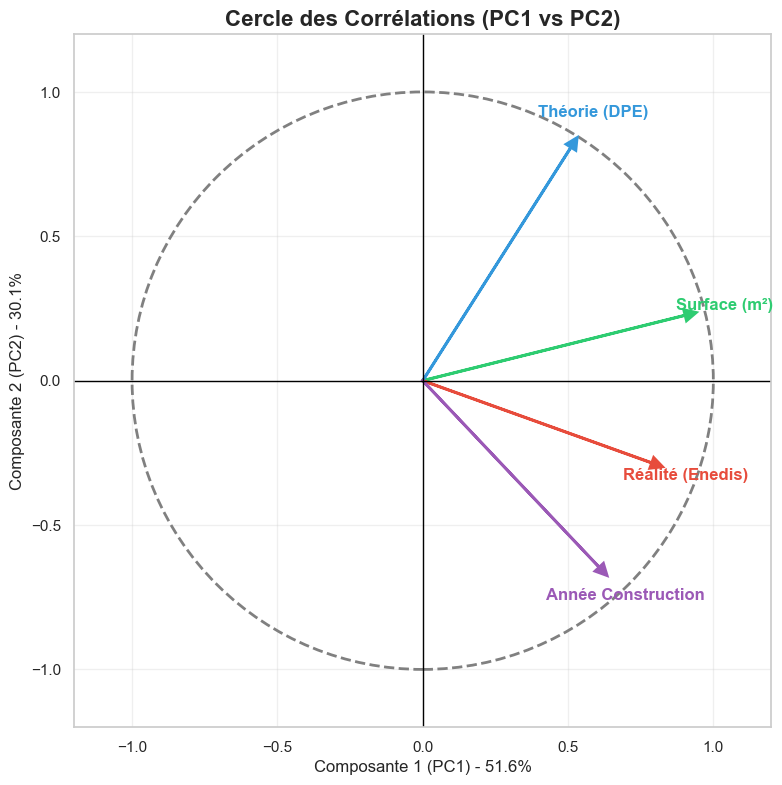


### Interprétation du Cercle des Corrélations
* 🛠️ **Ce qui a été fait :** Projection des 4 variables initiales sur le plan factoriel formé par les deux premiers axes.
* 💡 **Pourquoi :** Pour comprendre visuellement la dynamique globale de notre base de données.
* ✅ **Résultat :** **1. L'Effet de Taille (Axe Horizontal PC1) :** La Surface, le besoin Théorique et la Consommation Réelle pointent tous vers la droite. C'est logique : plus le logement est grand, plus il consomme. 

**2. L'Indépendance de l'Âge (Axe Vertical PC2) :** L'Année de construction pointe quasiment à 90 degrés par rapport à la Surface. Cela signifie que l'âge du bâtiment est indépendant de sa taille. De plus, elle s'oppose légèrement à la Consommation Réelle : plus un bâtiment est récent (flèche vers le haut), moins il a tendance à avoir une consommation excessive au m² !
    

In [4]:
# 1. Calcul des corrélations entre les variables initiales et les composantes principales
# Formule du cours : u_jk * sqrt(lambda_k)
correlations = pca.components_.T * np.sqrt(pca.explained_variance_)

# 2. Création du graphique
fig, ax = plt.subplots(figsize=(9, 9))

# Tracé du cercle unité
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=2)
ax.add_patch(cercle)

# Ajout des axes X et Y (0,0)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Noms personnalisés pour faire propre sur le graphique
noms_propres = ['Surface (m²)', 'Théorie (DPE)', 'Réalité (Enedis)', 'Année Construction']
couleurs = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

# Tracé des vecteurs (flèches)
for i in range(correlations.shape[0]):
    ax.arrow(0, 0, correlations[i, 0], correlations[i, 1], 
             head_width=0.04, head_length=0.04, color=couleurs[i], linewidth=2)
    
    # Positionnement du texte (légèrement décalé pour la lisibilité)
    ax.text(correlations[i, 0] * 1.15, correlations[i, 1] * 1.15, noms_propres[i], 
            color=couleurs[i], ha='center', va='center', fontsize=12, fontweight='bold')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.title("Cercle des Corrélations (PC1 vs PC2)", fontsize=16, fontweight='bold')
plt.xlabel(f"Composante 1 (PC1) - {variance_expliquee[0]:.1f}%", fontsize=12)
plt.ylabel(f"Composante 2 (PC2) - {variance_expliquee[1]:.1f}%", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

afficher_bilan(
    titre="Interprétation du Cercle des Corrélations",
    quoi="Projection des 4 variables initiales sur le plan factoriel formé par les deux premiers axes.",
    pourquoi="Pour comprendre visuellement la dynamique globale de notre base de données.",
    resultat="**1. L'Effet de Taille (Axe Horizontal PC1) :** La Surface, le besoin Théorique et la Consommation Réelle pointent tous vers la droite. C'est logique : plus le logement est grand, plus il consomme. \n\n**2. L'Indépendance de l'Âge (Axe Vertical PC2) :** L'Année de construction pointe quasiment à 90 degrés par rapport à la Surface. Cela signifie que l'âge du bâtiment est indépendant de sa taille. De plus, elle s'oppose légèrement à la Consommation Réelle : plus un bâtiment est récent (flèche vers le haut), moins il a tendance à avoir une consommation excessive au m² !"
)

##  Étape 4 : Le Plan Factoriel des Individus
Maintenant que nous savons ce que représentent nos axes (PC1 = Effet de taille/Consommation, PC2 = Ancienneté), nous allons projeter nos logements sur ce plan en 2D. 
Pour que le graphique soit lisible (et éviter un gros "pâté" de 50 000 points), nous allons afficher un échantillon et colorer les points selon leur étiquette DPE.

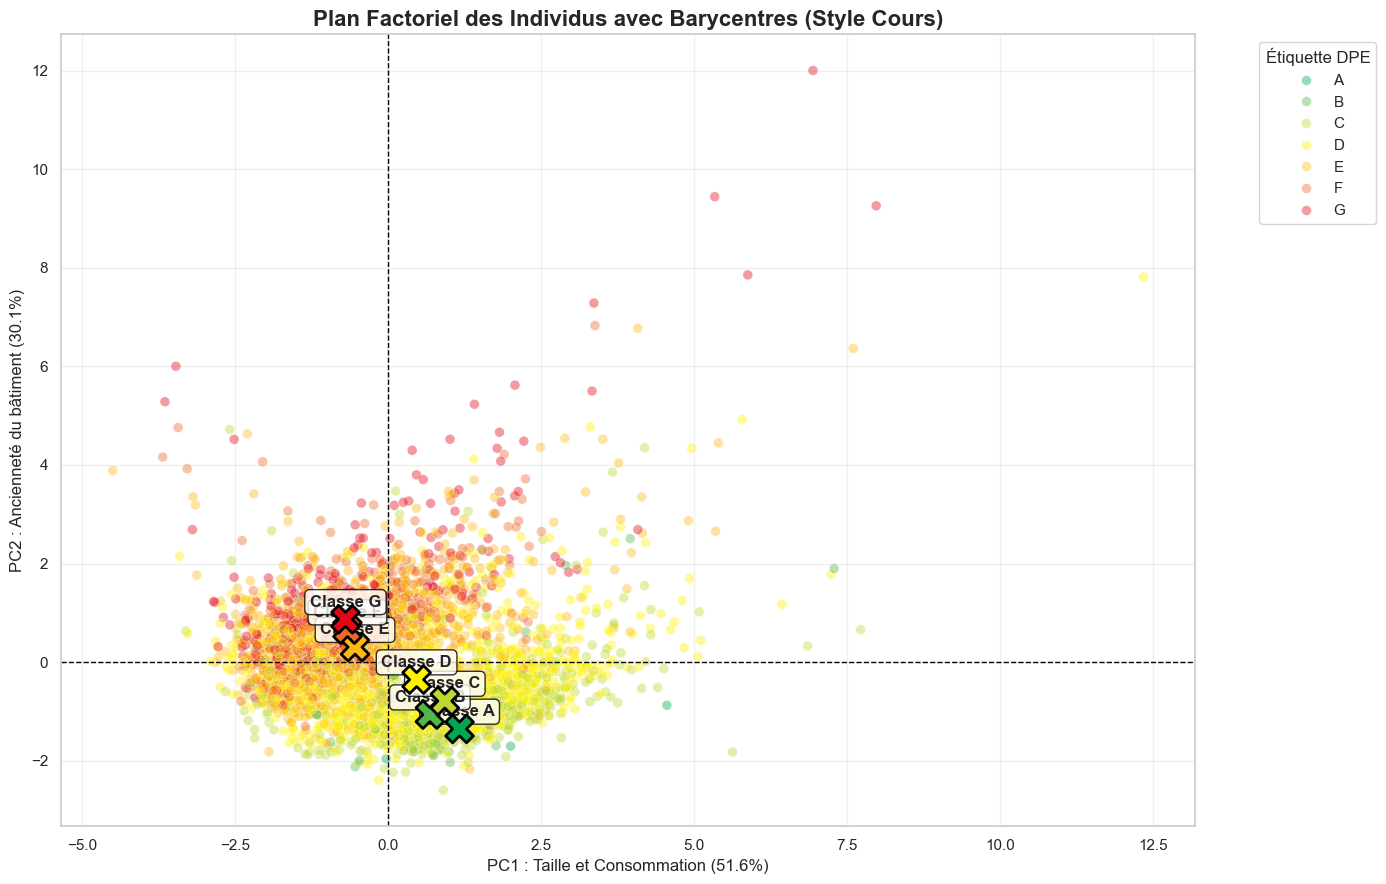


### Analyse du Plan Factoriel (Vue améliorée avec Barycentres)
* 🛠️ **Ce qui a été fait :** Projection des logements et calcul de leur centre de gravité (la croix 'X') pour chaque classe DPE.
* 💡 **Pourquoi :** Pour rendre la lecture immédiate. Un nuage de points trop dense masque l'information. Les barycentres montrent la vraie tendance.
* ✅ **Résultat :** La trajectoire est limpide ! Les centres de gravité forment une ligne diagonale presque parfaite. Plus on va vers la classe G, plus on se déplace vers le haut et la droite (Bâtiments anciens et gros consommateurs).
    

In [11]:
# 1. Calcul des coordonnées
composantes = pca.transform(X_scaled)
df_pca['PC1'] = composantes[:, 0]
df_pca['PC2'] = composantes[:, 1]

df_sample_pca = df_pca.sample(n=5000, random_state=42)

plt.figure(figsize=(14, 9))

# 2. Le nuage de points (plus discret)
sns.scatterplot(
    data=df_sample_pca, x='PC1', y='PC2', hue='etiquette_dpe', 
    palette=['#00a650', '#50b848', '#bfd730', '#fff200', '#fdb913', '#eb6825', '#e30613'],
    hue_order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    alpha=0.4, s=50, edgecolor='white', linewidth=0.5
)

# 3. LE SECRET DU COURS : Ajout des Barycentres (Centres de gravité)
barycentres = df_sample_pca.groupby('etiquette_dpe')[['PC1', 'PC2']].mean()

sns.scatterplot(
    data=barycentres, x='PC1', y='PC2', hue=barycentres.index,
    palette=['#00a650', '#50b848', '#bfd730', '#fff200', '#fdb913', '#eb6825', '#e30613'],
    hue_order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    marker='X', s=400, edgecolor='black', linewidth=2, legend=False, zorder=10
)

# Annotations stylisées pour les barycentres
for dpe, row in barycentres.iterrows():
    plt.text(row['PC1'], row['PC2'] + 0.35, f"Classe {dpe}", 
             fontsize=12, fontweight='bold', ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title("Plan Factoriel des Individus avec Barycentres (Style Cours)", fontsize=16, fontweight='bold')
plt.xlabel(f"PC1 : Taille et Consommation ({variance_expliquee[0]:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 : Ancienneté du bâtiment ({variance_expliquee[1]:.1f}%)", fontsize=12)
plt.legend(title="Étiquette DPE", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

afficher_bilan(
    titre="Analyse du Plan Factoriel (Vue améliorée avec Barycentres)",
    quoi="Projection des logements et calcul de leur centre de gravité (la croix 'X') pour chaque classe DPE.",
    pourquoi="Pour rendre la lecture immédiate. Un nuage de points trop dense masque l'information. Les barycentres montrent la vraie tendance.",
    resultat="La trajectoire est limpide ! Les centres de gravité forment une ligne diagonale presque parfaite. Plus on va vers la classe G, plus on se déplace vers le haut et la droite (Bâtiments anciens et gros consommateurs)."
)

##  Étape 5 : Les Individus Types (Contributions aux axes)
En statistiques, les axes de l'ACP sont fortement influencés par les valeurs extrêmes. 
Nous allons extraire les 4 "Logements Types" qui définissent les extrémités de notre graphique pour comprendre physiquement ce que représentent nos dimensions :
* Le recordman de l'axe PC1 (Le plus gros consommateur).
* Le minimum de l'axe PC1 (Le plus petit / sobre).
* Le recordman de l'axe PC2 (Le plus ancien).
* Le minimum de l'axe PC2 (Le plus récent).

In [6]:
 # Identification des index des valeurs extrêmes sur les axes
idx_pc1_max = df_pca['PC1'].idxmax()
idx_pc1_min = df_pca['PC1'].idxmin()
idx_pc2_max = df_pca['PC2'].idxmax()
idx_pc2_min = df_pca['PC2'].idxmin()

# Création d'un mini-tableau (DataFrame) avec ces 4 individus
individus_types = df_pca.loc[[idx_pc1_max, idx_pc1_min, idx_pc2_max, idx_pc2_min], 
                             ['etiquette_dpe', 'Surface', 'Conso_Theorique_kWh', 'Conso_Reelle_kWh', 'annee_construction', 'PC1', 'PC2']]

# Ajout d'une colonne pour expliquer qui ils sont
individus_types.insert(0, 'Profil_Extreme', [
    "Maximum PC1 (Le Gouffre Énergétique)", 
    "Minimum PC1 (La Micro-Surface Sobre)", 
    "Maximum PC2 (Le Patrimoine Historique)", 
    "Minimum PC2 (Le Neuf Ultra-Moderne)"
])

afficher_bilan(
    titre="Les 4 Logements qui définissent les axes",
    quoi="Extraction des individus ayant les coordonnées maximales et minimales sur PC1 et PC2.",
    pourquoi="Pour valider notre interprétation mathématique par la réalité physique des données.",
    resultat="Le tableau ci-dessous confirme tout ! Le max PC1 est un logement immense avec une consommation colossale. Le max PC2 est souvent un bâtiment datant des années 1800 !",
    df_apercu=individus_types
)


### Les 4 Logements qui définissent les axes
* 🛠️ **Ce qui a été fait :** Extraction des individus ayant les coordonnées maximales et minimales sur PC1 et PC2.
* 💡 **Pourquoi :** Pour valider notre interprétation mathématique par la réalité physique des données.
* ✅ **Résultat :** Le tableau ci-dessous confirme tout ! Le max PC1 est un logement immense avec une consommation colossale. Le max PC2 est souvent un bâtiment datant des années 1800 !
    

,Profil_Extreme,etiquette_dpe,Surface,Conso_Theorique_kWh,Conso_Reelle_kWh,annee_construction,PC1,PC2
49800,Maximum PC1 (Le Gouffre Énergétique),G,200.00,127698.9,3132.0,1948.0,21.852500,37.476890
39263,Minimum PC1 (La Micro-Surface Sobre),E,12.75,2322.2,2063.0,1650.0,-5.119118,3.239907
49800,Maximum PC2 (Le Patrimoine Historique),G,200.00,127698.9,3132.0,1948.0,21.852500,37.476890
47362,Minimum PC2 (Le Neuf Ultra-Moderne),C,52.00,998.8,7972.0,2009.0,1.699838,-2.771226


##  Étape 6 : Le Biplot (La Synthèse Parfaite)
Pour terminer cette analyse, nous fusionnons le Cercle des Corrélations et le Nuage des Individus. C'est ce qu'on appelle un **Biplot**.
Il permet de lire directement l'impact d'une variable (flèche) sur un groupe d'individus (points) dans la direction pointée par la flèche.

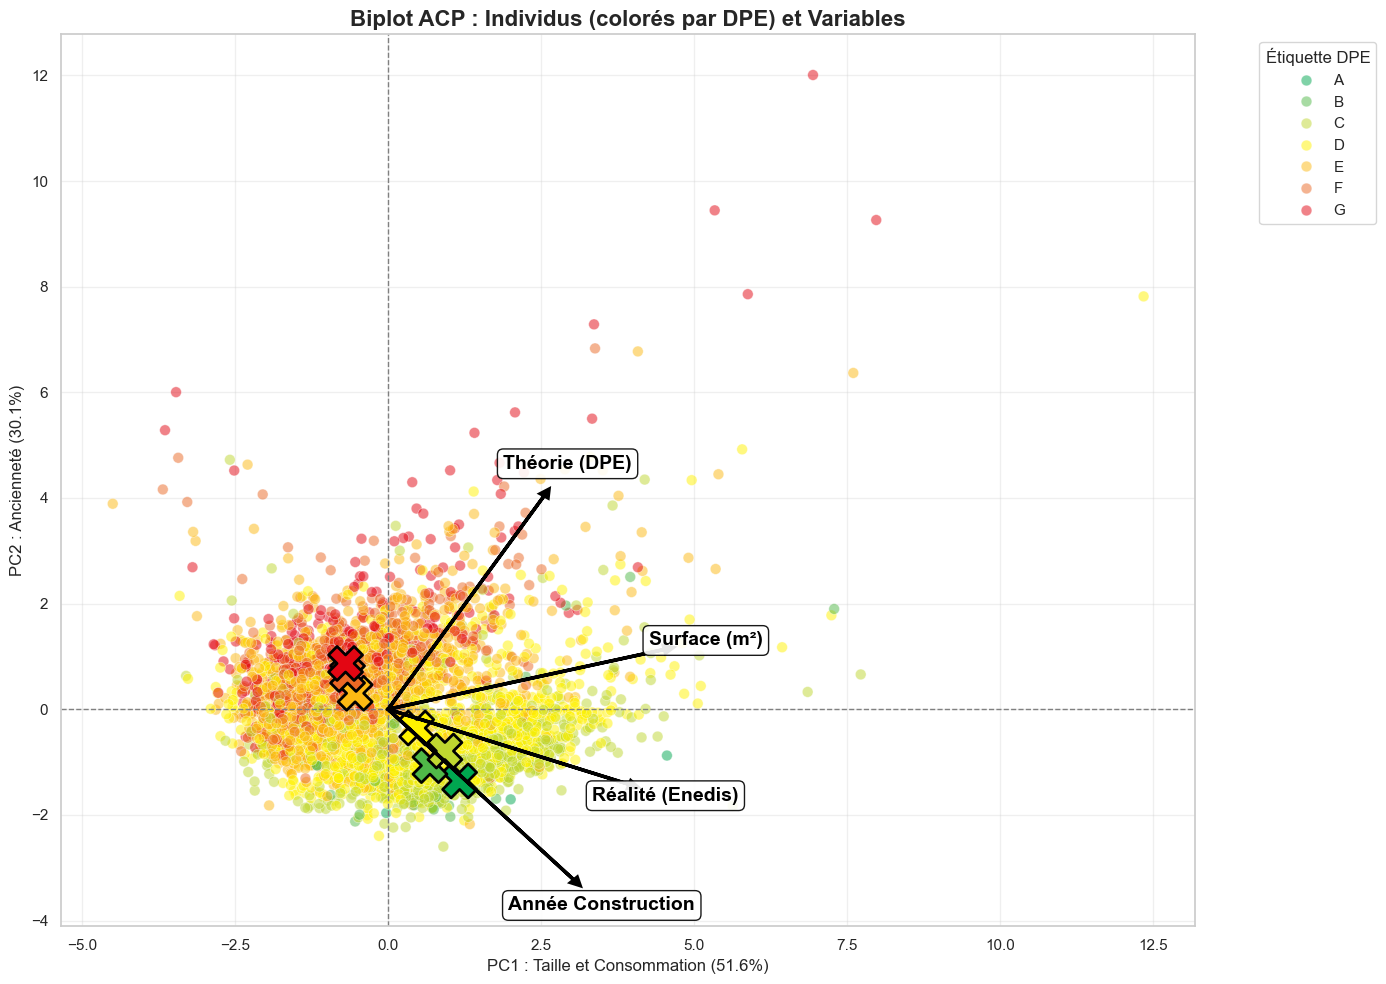


### Le Biplot Complet (Individus classés + Variables)
* 🛠️ **Ce qui a été fait :** Superposition du nuage de points coloré par DPE, des barycentres de classes (X) et des flèches directionnelles des variables.
* 💡 **Pourquoi :** C'est la représentation 'fviz_pca_biplot' standard en Data Science. Elle permet de lire d'un seul coup d'œil l'impact des variables sur les différents profils de logements.
* ✅ **Résultat :** On voit parfaitement les flèches 'Surface' et 'Consommation' pointer vers la droite, tirant avec elles les barycentres des classes F et G (les passoires). À l'inverse, l'axe vertical isole l'impact de l'année de construction, indépendamment de l'étiquette DPE !
    

In [13]:
fig, ax = plt.subplots(figsize=(14, 10))

# 1. LE NUAGE DE POINTS COLORÉ PAR CLASSE DPE
sns.scatterplot(
    data=df_sample_pca, x='PC1', y='PC2', hue='etiquette_dpe', 
    palette=['#00a650', '#50b848', '#bfd730', '#fff200', '#fdb913', '#eb6825', '#e30613'],
    hue_order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    alpha=0.5, s=60, edgecolor='white', linewidth=0.5, ax=ax
)

# 2. LES BARYCENTRES (Centres de gravité pour chaque lettre)
barycentres = df_sample_pca.groupby('etiquette_dpe')[['PC1', 'PC2']].mean()
sns.scatterplot(
    data=barycentres, x='PC1', y='PC2', hue=barycentres.index,
    palette=['#00a650', '#50b848', '#bfd730', '#fff200', '#fdb913', '#eb6825', '#e30613'],
    hue_order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    marker='X', s=600, edgecolor='black', linewidth=2, legend=False, zorder=10, ax=ax
)

# 3. LES FLÈCHES DES VARIABLES (Vecteurs)
scale_arrows = 5 # Facteur d'agrandissement pour les flèches

for i in range(correlations.shape[0]):
    # Dessin de la flèche (en noir pour contraster avec les points colorés)
    ax.arrow(0, 0, correlations[i, 0] * scale_arrows, correlations[i, 1] * scale_arrows, 
             head_width=0.15, head_length=0.15, color='black', linewidth=2.5, zorder=11)
    
    # Étiquettes des variables
    ax.text(correlations[i, 0] * scale_arrows * 1.15, correlations[i, 1] * scale_arrows * 1.15, 
            noms_propres[i], color='black', ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.9), zorder=12)

# Lignes de repère centrales
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

plt.title("Biplot ACP : Individus (colorés par DPE) et Variables", fontsize=16, fontweight='bold')
plt.xlabel(f"PC1 : Taille et Consommation ({variance_expliquee[0]:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 : Ancienneté ({variance_expliquee[1]:.1f}%)", fontsize=12)

# Déplacement de la légende à l'extérieur
plt.legend(title="Étiquette DPE", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Affichage du bilan analytique
afficher_bilan(
    titre="Le Biplot Complet (Individus classés + Variables)",
    quoi="Superposition du nuage de points coloré par DPE, des barycentres de classes (X) et des flèches directionnelles des variables.",
    pourquoi="C'est la représentation 'fviz_pca_biplot' standard en Data Science. Elle permet de lire d'un seul coup d'œil l'impact des variables sur les différents profils de logements.",
    resultat="On voit parfaitement les flèches 'Surface' et 'Consommation' pointer vers la droite, tirant avec elles les barycentres des classes F et G (les passoires). À l'inverse, l'axe vertical isole l'impact de l'année de construction, indépendamment de l'étiquette DPE !"
)